In [97]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
dir(iris)
iris.target_names


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [98]:
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


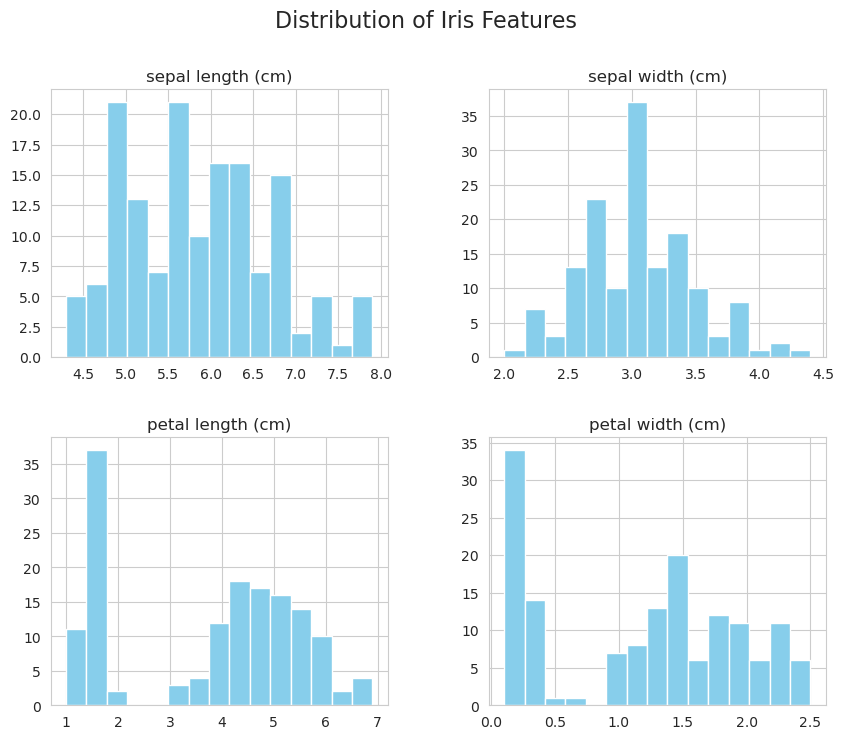

In [99]:
# Plot histogram for each feature
df.iloc[:, :-1].hist(figsize=(10, 8), bins=15, color='skyblue')
plt.suptitle("Distribution of Iris Features", fontsize=16)
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

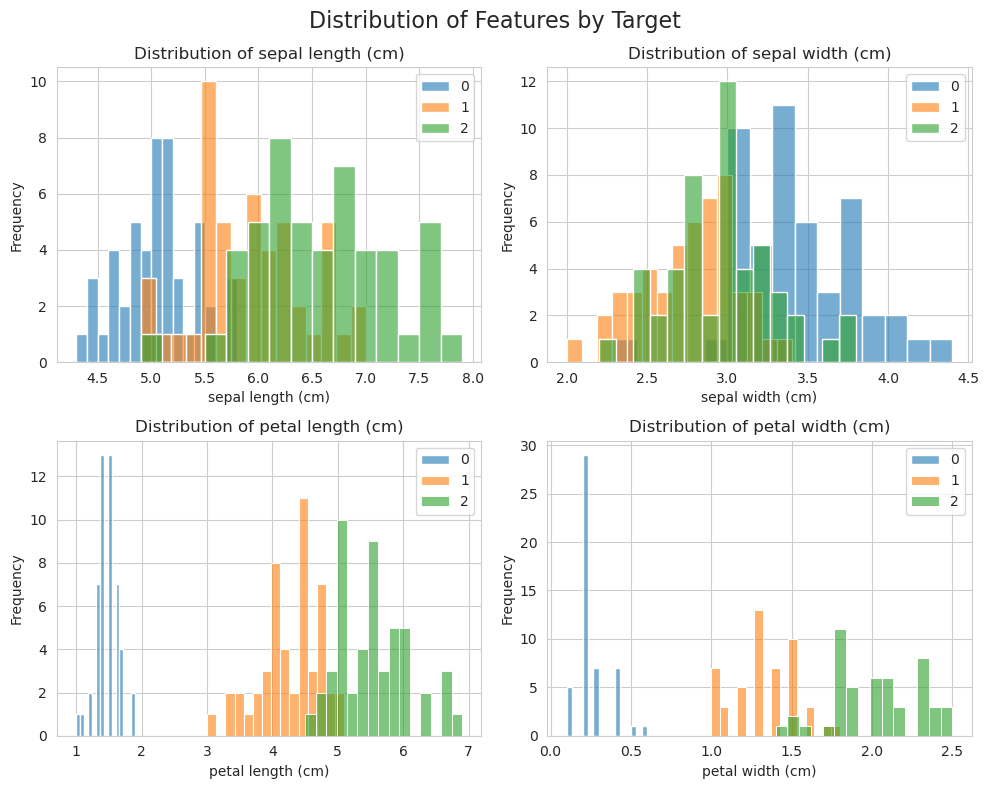

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df has a 'target' column as well
sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

# List of features (excluding the 'target' column)
features = df.columns[:-1]  # or df.iloc[:, :-1].columns

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    for target_class in df['target'].unique():
        subset = df[df['target'] == target_class]
        sns.histplot(subset[feature], bins=15, label=str(target_class), kde=False, alpha=0.6)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()

plt.suptitle("Distribution of Features by Target", fontsize=16)
plt.tight_layout()
plt.show()

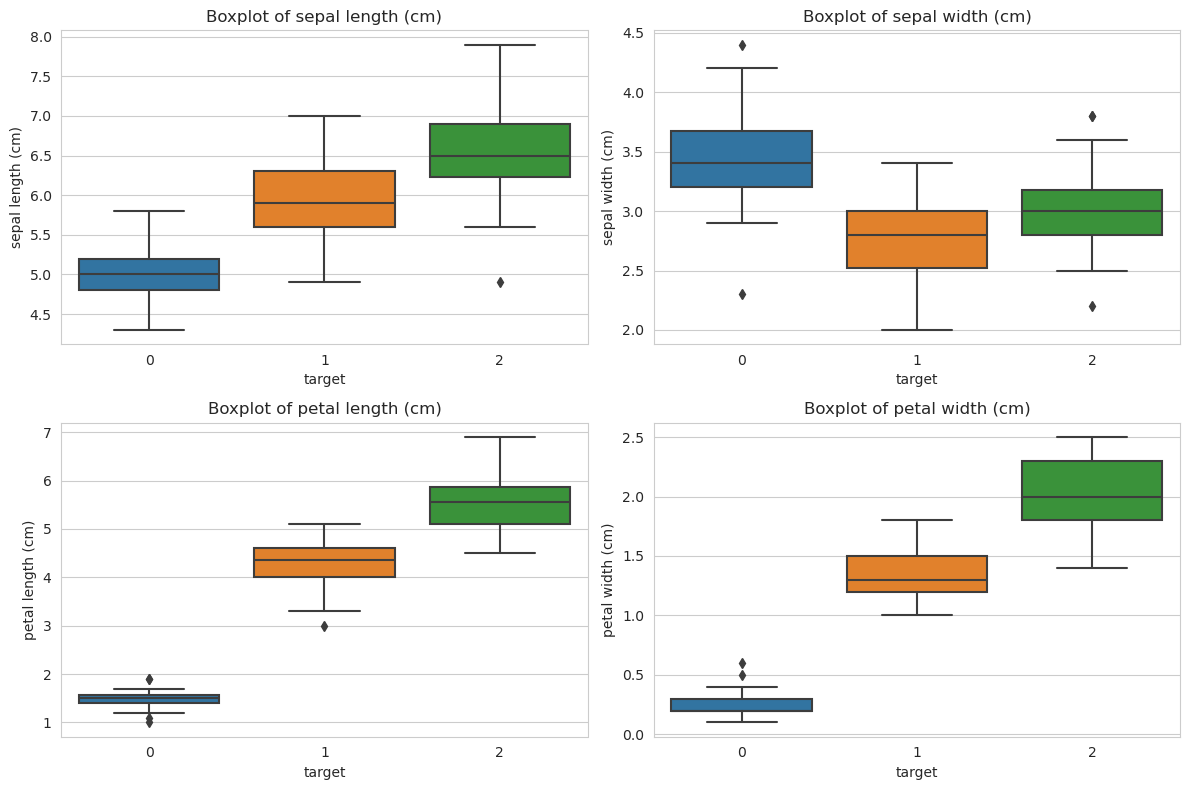

In [101]:
# Plot boxplots for all features
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

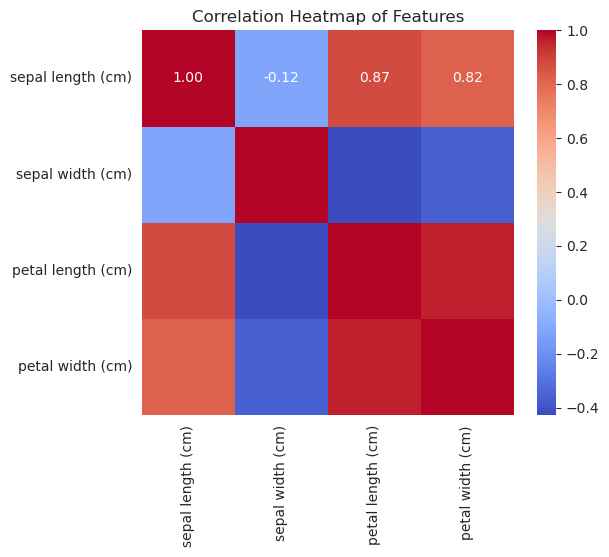

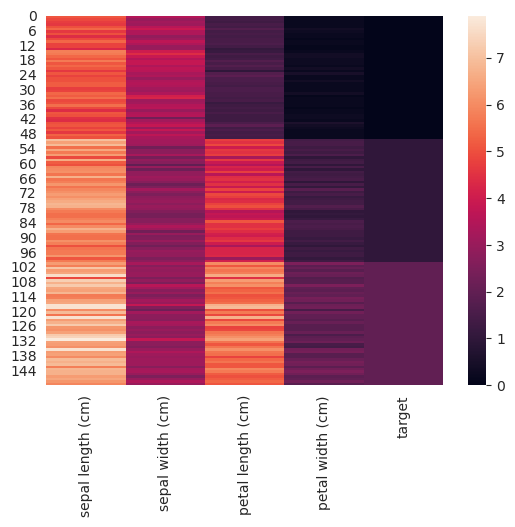

In [102]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()
sns.heatmap(df)
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

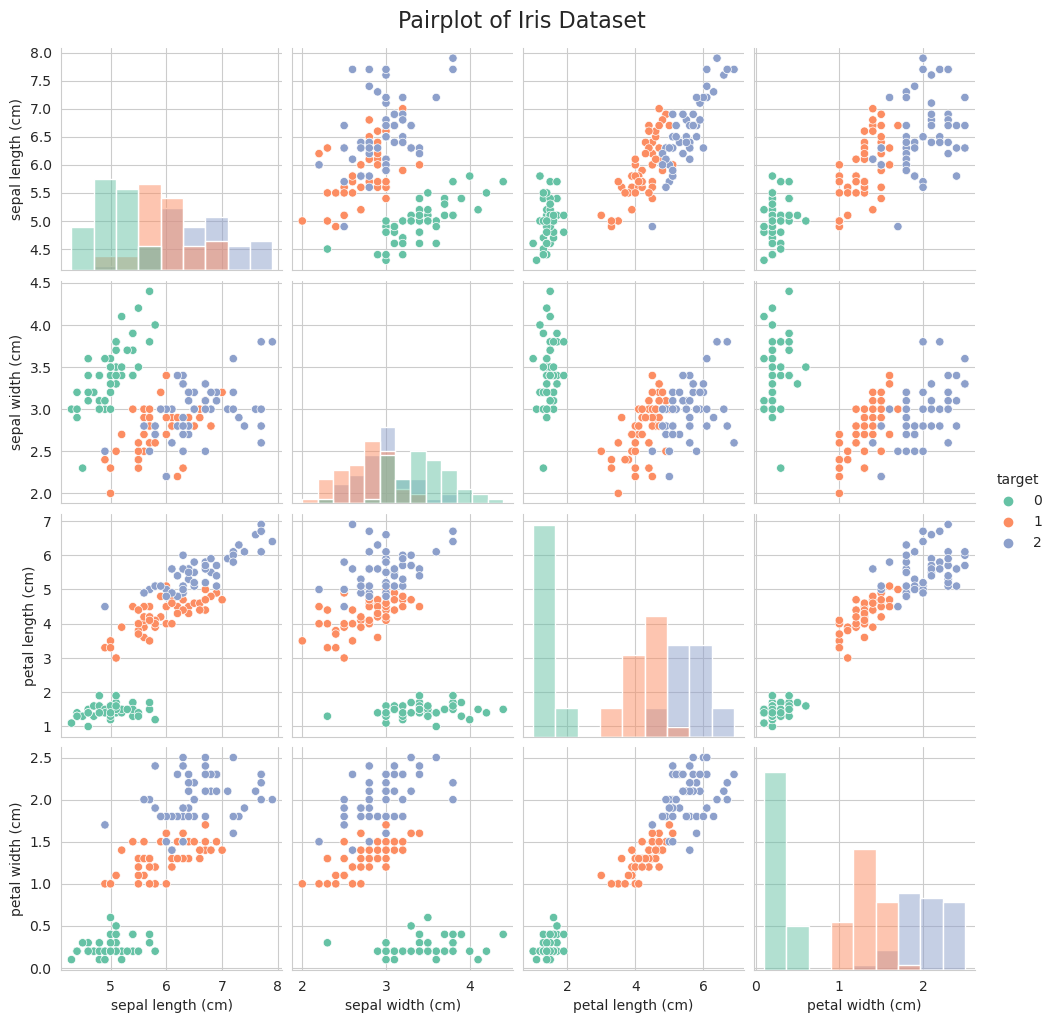

In [103]:
# Pairplot with species labels
sns.pairplot(df, hue="target", diag_kind="hist", palette="Set2")
plt.suptitle("Pairplot of Iris Dataset", y=1.02, fontsize=16)
plt.show()

In [104]:
from sklearn.cluster import KMeans

inertia = []
for k in range(2,6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df.iloc[:, :-1])
    inertia.append(model.inertia_)
inertia

[152.34795176035792, 78.85144142614601, 57.228473214285714, 46.44618205128205]

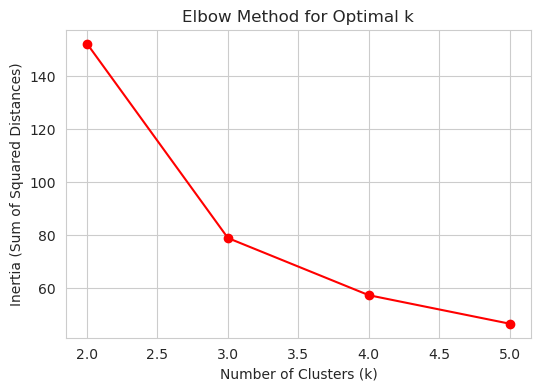

In [105]:
# Plot Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(range(2, 6), inertia, marker='o', color='red')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.grid(True)
plt.show()

In [106]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(df.iloc[:, :-1])
df.head


<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

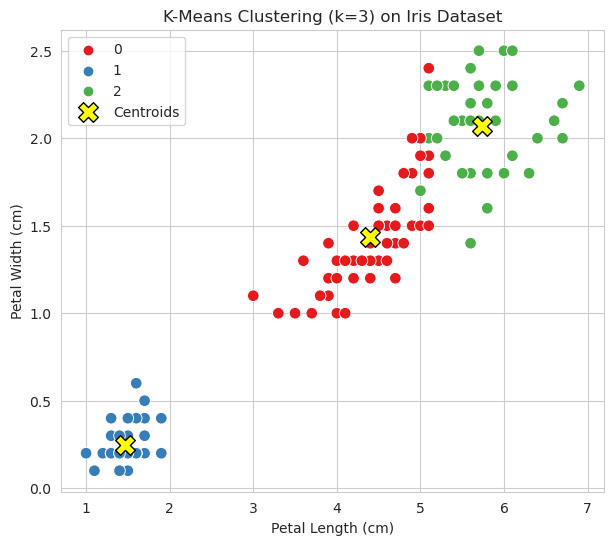

In [107]:
# Scatter plot of clusters
plt.figure(figsize=(7, 6))
sns.scatterplot(x=df["petal length (cm)"], 
                y=df["petal width (cm)"], 
                hue=df["cluster"], 
                palette="Set1", 
                s=70)
plt.scatter(kmeans.cluster_centers_[:, 2], 
            kmeans.cluster_centers_[:, 3], 
            s=200, c="yellow", marker="X", edgecolor="black", label="Centroids")
plt.title("K-Means Clustering (k=3) on Iris Dataset")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

In [108]:
from sklearn.metrics import confusion_matrix, accuracy_score


# Real labels
y_true = df["target"]

# Predicted clusters
y_pred = df["cluster"]

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 0 50  0]
 [48  0  2]
 [14  0 36]]


In [109]:
# Reorder cluster labels to best match true labels
from scipy.stats import mode
import numpy as np 

labels = np.zeros_like(y_pred)
for i in range(3):
    mask = (y_pred == i)
    labels[mask] = mode(y_true[mask], keepdims=True)[0]

# Calculate accuracy
acc = accuracy_score(y_true, labels)
print(f"Accuracy of K-Means clustering: {acc:.2f}")


Accuracy of K-Means clustering: 0.89


In [110]:
from sklearn.metrics import adjusted_rand_score, silhouette_score
# Adjusted Rand Index
ari = adjusted_rand_score(y_true, y_pred)

# Silhouette Score
silhouette = silhouette_score(df.iloc[:, :-2], y_pred)

print(f"Adjusted Rand Index (ARI): {ari:.2f}")
print(f"Silhouette Score: {silhouette:.2f}")

Adjusted Rand Index (ARI): 0.73
Silhouette Score: 0.55


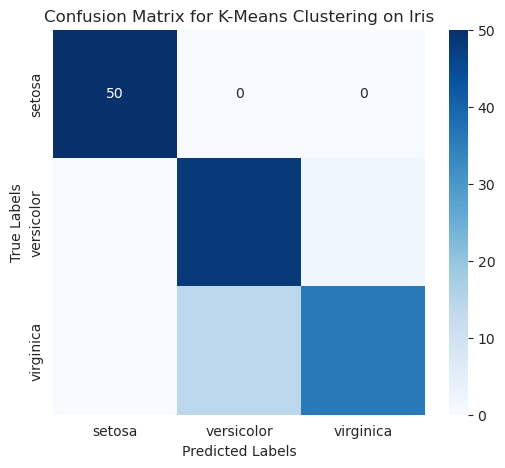

In [111]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, labels), annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for K-Means Clustering on Iris")
plt.show()

In [112]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-2]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.2f}")

Logistic Regression Accuracy: 0.97


In [127]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.2f}")

KNN Accuracy: 0.97


In [115]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.2f}")

SVM Accuracy: 1.00


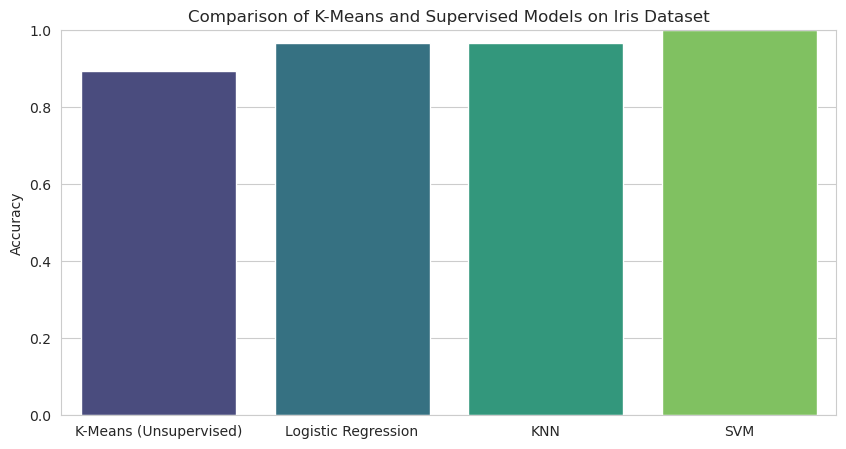

In [128]:
results = {
    "K-Means (Unsupervised)": acc,
    "Logistic Regression": acc_lr,
    "KNN": acc_knn,
    "SVM": acc_svm
}

# Convert to DataFrame for visualization
results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=results_df.index, y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0, 1)
plt.title("Comparison of K-Means and Supervised Models on Iris Dataset")
plt.ylabel("Accuracy")
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/hom

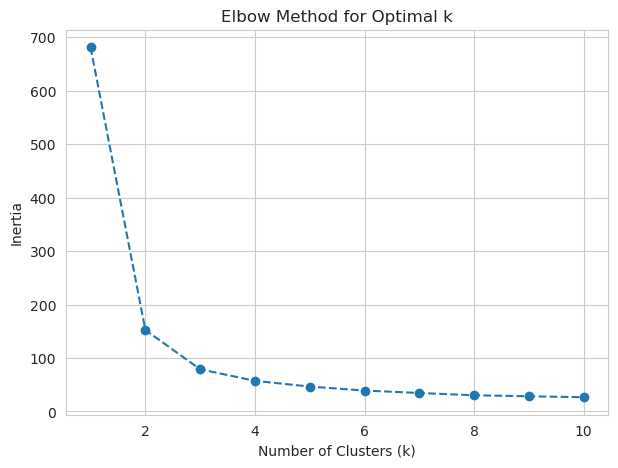

In [130]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(7,5))
plt.plot(K, inertia, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/hom

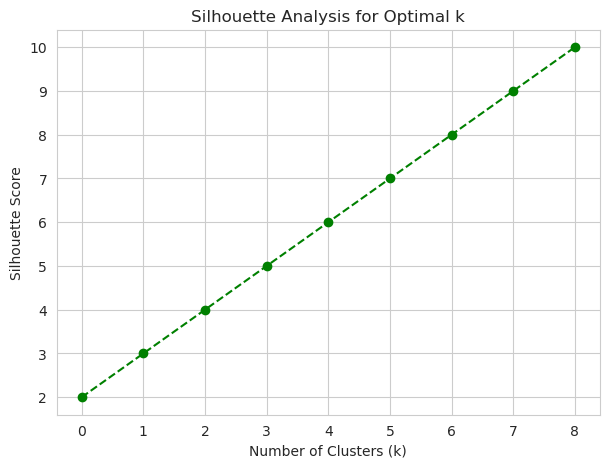

In [132]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):  # Silhouette نیاز به حداقل 2 خوشه دارد
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(7,5))
plt.plot(range(2, 11), data=silhouette_scores, marker='o', linestyle='--', color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.show()